# Mapas Tendencias
***
Esté código busca representar las tendencias medias por cuencas usando la máscara creada en la carpeta Crea Cuencas. Para ello se usan los ficheros tendecy obtenidos en calcula tendencia y se promedia las tendencias por cuencas. Para ellos los pasos a seguir son los siguientes:
1. Abrir el fichero con las tendencias
2. Calcular el promedio por máscara
3. Representar

In [1]:
import numpy as np
import xarray as xr
import pandas as pd

import matplotlib.pyplot as plt
import cartopy
import cartopy.feature as cfeature
import cartopy.crs as ccrs
from matplotlib.colors import ListedColormap, BoundaryNorm

from tqdm import tqdm


In [16]:
resolution = '25'
dates = '1990_2025'
pressure_max = '5000'
pressure_min = '4000'
pressure_code = pressure_min[0] + pressure_max[0] + 'k'

### Apertura de los datos de tendencia y estructura

In [17]:
ds = xr.open_dataset(f'./Data/tendency/tendency_{dates}_{resolution}_{pressure_code}.nc')
ds

<xarray.Dataset> Size: 1GB
Dimensions:    (latitude: 563, longitude: 1355, n_prof: 78)
Coordinates:
  * latitude   (latitude) float64 5kB -77.75 -77.5 -77.25 ... 62.75 63.0 63.25
  * longitude  (longitude) float64 11kB -180.0 -179.8 -179.5 ... 179.8 180.0
    n          (latitude, longitude) float64 6MB ...
    batimetry  (latitude, longitude) float64 6MB ...
    mask       (latitude, longitude) float64 6MB ...
    basin      (latitude, longitude) <U18 55MB ...
    surface    (latitude, longitude) float64 6MB ...
  * n_prof     (n_prof) int64 624B 0 1 2 3 4 5 6 7 8 ... 70 71 72 73 74 75 76 77
    times      (latitude, longitude, n_prof) datetime64[ns] 476MB ...
Data variables:
    profiles   (latitude, longitude, n_prof) float64 476MB ...
    tendency   (latitude, longitude) float64 6MB ...

Empezamos calculando la media y desviación por cuencas

In [18]:
# Importing the unique values of the mask
cuencas = np.unique(ds.mask.values)

basin_idx = [] # Number of the basin
basin_mean = [] # Tendency mean asociated
basin_std = [] # Tendency std asociated

# Iterate for every 'cuenca'
for cuenca in cuencas:
    if np.isnan(cuenca): # Skip is cuenca is Nan
        continue

    else:
        tendency = ds.tendency.where(ds.mask == cuenca).values
        tendency_mean = np.nanmean(tendency)
        tendency_std = np.nanstd(tendency)
        basin_idx.append(cuenca)
        basin_mean.append(tendency_mean)
        basin_std.append(tendency_std)

C:\Users\ismae\AppData\Local\Temp\ipykernel_13608\285652899.py:15: RuntimeWarning: Mean of empty slice
  tendency_mean = np.nanmean(tendency)
c:\Users\ismae\miniconda3\envs\practicas\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\ismae\AppData\Local\Temp\ipykernel_13608\285652899.py:15: RuntimeWarning: Mean of empty slice
  tendency_mean = np.nanmean(tendency)
c:\Users\ismae\miniconda3\envs\practicas\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\ismae\AppData\Local\Temp\ipykernel_13608\285652899.py:15: RuntimeWarning: Mean of empty slice
  tendency_mean = np.nanmean(tendency)
c:\Users\ismae\miniconda3\envs\practicas\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var 

Una vez tenemos hechas las mismas, creamos un dataset con dos variables nuevas, tendency mean y std

In [19]:
# Load the values of lat, lon and mask
latitudes = ds.latitude.values
longitudes = ds.longitude.values
mask = ds.mask.values

# Creating empty matrix
tendency_mean = np.full((len(latitudes), len(longitudes)), np.nan)
tendency_std = np.full((len(latitudes), len(longitudes)), np.nan)

# Iterate for each basin
for k, basin in enumerate(basin_idx):
    tendency_mean = np.where(mask == basin, basin_mean[k], tendency_mean)
    tendency_std = np.where(mask == basin, basin_std[k], tendency_std)


In [20]:
# Adding the variable to dataset
ds['tendency_mean'] = (('latitude', 'longitude'), tendency_mean)
ds['tendency_std'] = (('latitude', 'longitude'), tendency_std)

## Mapa tendencias

<>:35: SyntaxWarning: invalid escape sequence '\p'
<>:35: SyntaxWarning: invalid escape sequence '\p'
C:\Users\ismae\AppData\Local\Temp\ipykernel_13608\1171902044.py:35: SyntaxWarning: invalid escape sequence '\p'
  ax.text(mean_lon,mean_lat, f'{basin_mean[k]:.3f}$\pm${basin_std[k]:.3f}', transform=ccrs.PlateCarree(),fontsize=12,ha='center',va='center',bbox=dict(facecolor='white', alpha=0.8,edgecolor='none'))


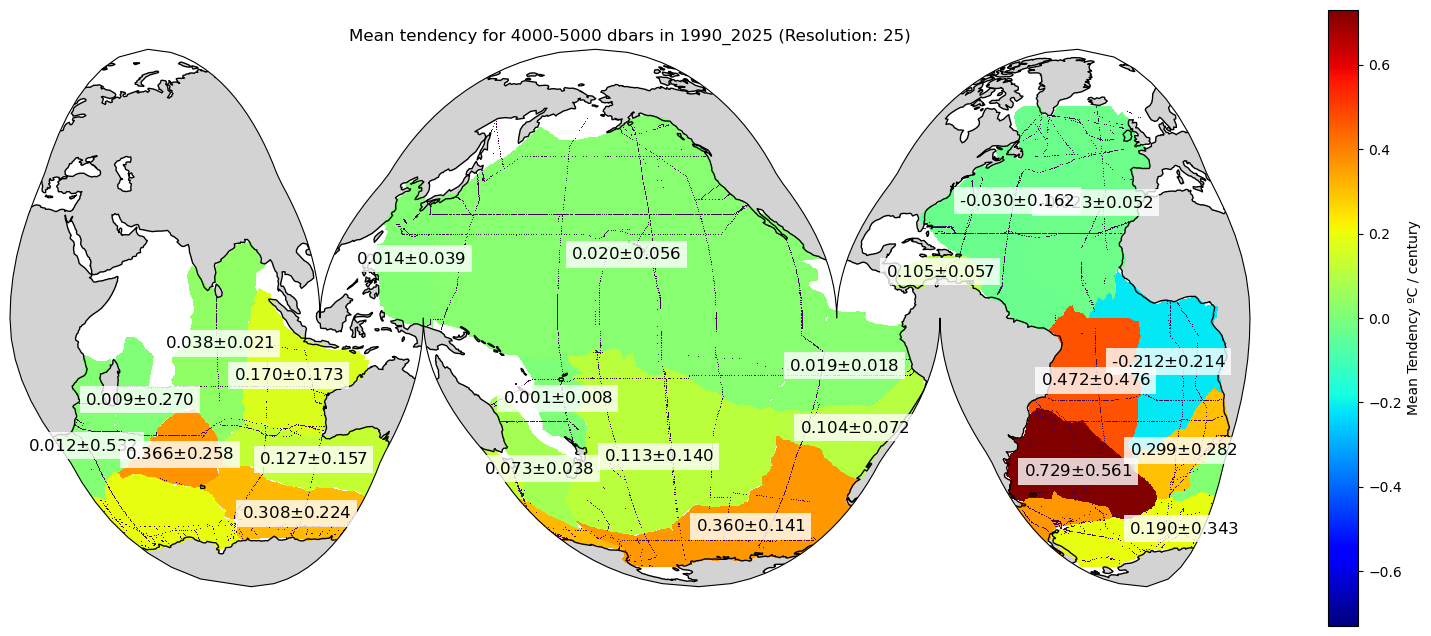

In [21]:
# Creating figure
fig, ax = plt.subplots(figsize=(20,10),
    subplot_kw={'projection': ccrs.InterruptedGoodeHomolosine(central_longitude=-160,emphasis='ocean')})

# Ploting mean
means = ds.tendency_mean.plot(ax = ax, cmap = "jet", transform = ccrs.PlateCarree(),  add_colorbar = False)

# Colorbar
fig.colorbar(mappable = means, shrink = 0.8, label = 'Mean Tendency ºC / century')

# Plotting ocupations
ds.n.plot(ax = ax, transform = ccrs.PlateCarree(), add_colorbar = False)

# Plotting features
ax.set_global()
ax.coastlines(resolution='110m')
ax.add_feature(cfeature.LAND, facecolor='lightgray')

# Title
ax.set_title(f'Mean tendency for {pressure_min}-{pressure_max} dbars in {dates} (Resolution: {resolution})')

# Plotting text
for k, basin in enumerate(basin_idx):
    if not np.isnan(basin_mean[k]):
        latitude = ds.latitude.where(ds.mask == basin).values
        longitude = ds.longitude.where(ds.mask == basin).values

        # Normal mean for latitude
        mean_lat = np.nanmean(latitude)

        # Ciruclar mean for longitude
        lon_rad = np.radians(longitude)
        mean_lon = np.degrees(np.arctan2(np.nanmean(np.sin(lon_rad)), np.nanmean(np.cos(lon_rad))))

        ax.text(mean_lon,mean_lat, f'{basin_mean[k]:.3f}$\pm${basin_std[k]:.3f}', transform=ccrs.PlateCarree(),fontsize=12,ha='center',va='center',bbox=dict(facecolor='white', alpha=0.8,edgecolor='none'))
    else:
        continue

# Save plot
plt.savefig(f'./plots/Mapas_Tendencias/Mean_Tendency_{dates}_{resolution}_{pressure_code}.png')

### Cerrar todos los archivos

In [22]:
ds.close()
plt.close('all')